In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.amp import autocast, GradScaler

# Variáveis principais e verificação do da GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Treinando na: {device}")
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
EPOCHS = 5


Treinando na: cuda


In [2]:
# Coleta as imagens do banco de dados 
transformacao = v2.Compose([
    v2.Resize((224, 224)),                 
    v2.ToImage(), 
    v2.ToDtype(torch.float32, scale=True)
])

pasta_treino = "MNIST-JPG/train"
pasta_teste = "MNIST-JPG/test"

training_data = datasets.ImageFolder(root=pasta_treino, transform=transformacao)
test_data = datasets.ImageFolder(root=pasta_teste, transform=transformacao)

train_dataloader = DataLoader(training_data, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)
test_dataloader = DataLoader(test_data, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)


# Estrutura da rede neural
class ConvolutionalNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bloco 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        # Bloco 2
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        #Bloco 3
        self.conv5 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.conv6 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(256)
        self.conv7 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.bn7 = nn.BatchNorm2d(256)
        #bloco 4
        self.conv8 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1)
        self.bn8 = nn.BatchNorm2d(512)
        self.conv9 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1)
        self.bn9 = nn.BatchNorm2d(512)
        self.conv10 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1)
        self.bn10 = nn.BatchNorm2d(512)
        #Bloco 5
        self.conv11 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1)
        self.bn11 = nn.BatchNorm2d(512)
        self.conv12 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1)
        self.bn12 = nn.BatchNorm2d(512)
        self.conv13 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1)
        self.bn13 = nn.BatchNorm2d(512)
        # Bloco 6 final
        self.fc1 = nn.Linear(512 * 7 * 7, 4096)
        self.fc2 = nn.Linear(4096, 4096)
        self.fc3 = nn.Linear(4096, 10)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        # Bloco 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        # Bloco 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        # Bloco 3
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool(F.relu(self.bn7(self.conv7(x))))
        # Bloco 4
        x = F.relu(self.bn8(self.conv8(x)))
        x = F.relu(self.bn9(self.conv9(x)))
        x = self.pool(F.relu(self.bn10(self.conv10(x))))
        # Bloco 5
        x = F.relu(self.bn11(self.conv11(x)))
        x = F.relu(self.bn12(self.conv12(x)))
        x = self.pool(F.relu(self.bn13(self.conv13(x))))
        # Bloco final
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        logits = self.fc3(x)
        return logits

In [9]:
# Envia pra GPU e otimizador Adam com LEARNING_RATE = 1e-4
model = ConvolutionalNeuralNetwork().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Ensino da rede
def train_loop(dataloader, model, loss_fn, optimizer, scaler):
    model.train() 
    size = len(dataloader.dataset)
    
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()

        with autocast(device_type='cuda', dtype=torch.float16):
            pred = model(X)
            loss = loss_fn(pred, y)

        # Backpropagation
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        if batch % 100 == 0:
            loss_valor, atual = loss.item(), batch * BATCH_SIZE + len(X)
            print(f"Loss: {loss_valor:>7f}  [{atual:>5d}/{size:>5d}]")

# Teste da rede
def test_loop(dataloader, model, loss_fn):
    model.eval() 
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    print(f"Resultado do Teste: \n Precisão: {(100 * correct / size):>0.1f}%, Loss: {(test_loss / num_batches):>8f} \n")

scaler = GradScaler('cuda')

# Ciclo de épocas
for t in range(EPOCHS):
    print(f"Época {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer, scaler)
    test_loop(test_dataloader, model, loss_fn)
print("Treinamento Concluído!")

# Salva os pesos em um arquivo
torch.save(model.state_dict(), "pesoscnn.pth")
print("Modelo salvo")

Época 1
-------------------------------
Loss: 2.400391  [   16/60000]
Loss: 0.174550  [ 1616/60000]
Loss: 0.075517  [ 3216/60000]
Loss: 0.115338  [ 4816/60000]
Loss: 0.437005  [ 6416/60000]
Loss: 0.003551  [ 8016/60000]
Loss: 0.022981  [ 9616/60000]
Loss: 0.618728  [11216/60000]
Loss: 0.183694  [12816/60000]
Loss: 0.063884  [14416/60000]
Loss: 0.112838  [16016/60000]
Loss: 0.173198  [17616/60000]
Loss: 0.056309  [19216/60000]
Loss: 0.174672  [20816/60000]
Loss: 0.154868  [22416/60000]
Loss: 0.036751  [24016/60000]
Loss: 0.031818  [25616/60000]
Loss: 0.088293  [27216/60000]
Loss: 0.008397  [28816/60000]
Loss: 0.001589  [30416/60000]
Loss: 0.462327  [32016/60000]
Loss: 0.028113  [33616/60000]
Loss: 0.295362  [35216/60000]
Loss: 0.077211  [36816/60000]
Loss: 0.027060  [38416/60000]
Loss: 0.000235  [40016/60000]
Loss: 0.001487  [41616/60000]
Loss: 0.030841  [43216/60000]
Loss: 0.012300  [44816/60000]
Loss: 0.183742  [46416/60000]
Loss: 0.312246  [48016/60000]
Loss: 0.023934  [49616/60000]


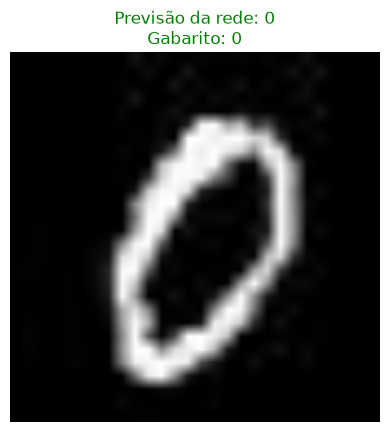

In [15]:
# Pega uma imagem do banco de dados e faz a previsão
classes = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]

indice = 13  # Mude este valor para testar outras imagens
imagem, label_real = test_data[indice][0], test_data[indice][1]

model.eval()
with torch.no_grad():
    imagem_gpu = imagem.unsqueeze(0).to(device)
    
    pred = model(imagem_gpu)
    indice_previsto = pred.argmax(1).item()
    
    nome_previsto = classes[indice_previsto]
    nome_real = classes[label_real]

draw_image = imagem.permute(1, 2, 0).cpu().numpy()

plt.imshow(draw_image)
cor_do_texto = "green" if indice_previsto == label_real else "red"
plt.title(f"Previsão da rede: {nome_previsto}\nGabarito: {nome_real}", color=cor_do_texto)
plt.axis("off")
plt.show()

In [6]:
model = ConvolutionalNeuralNetwork().to(device)

model.load_state_dict(torch.load("pesoscnn.pth", weights_only=True))
model.eval() 
print("Carregado")

Carregado


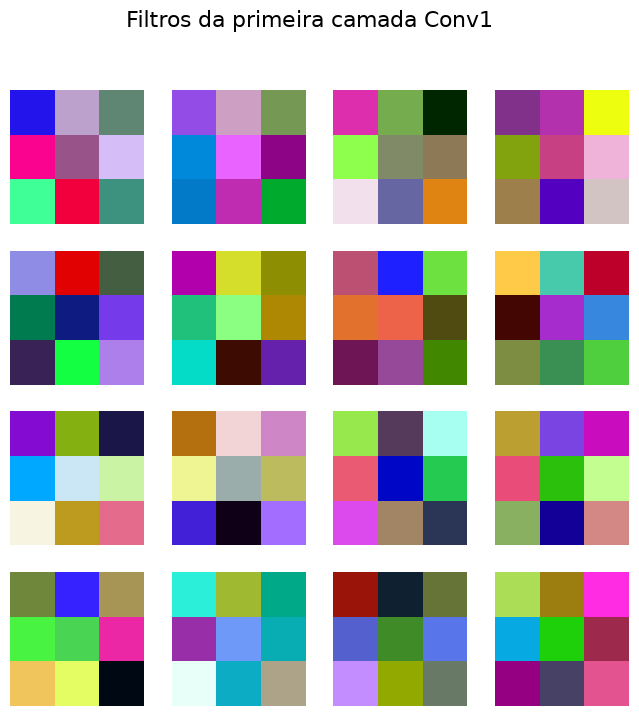

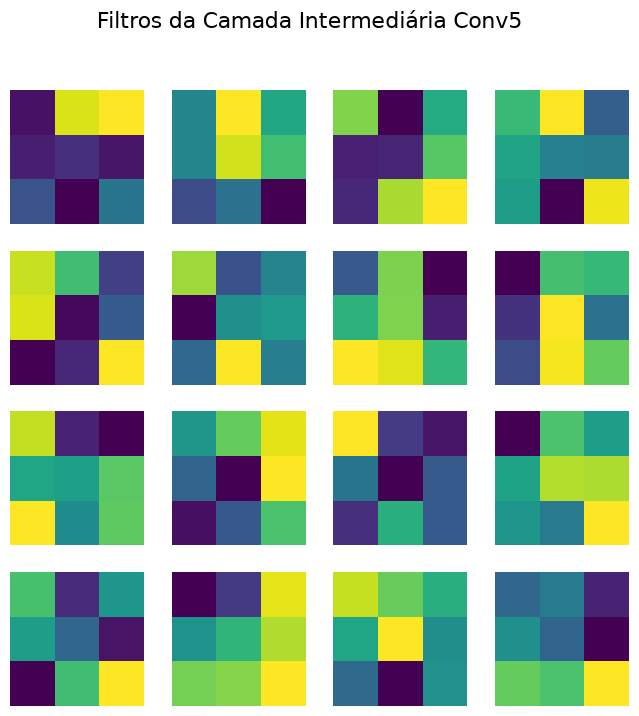

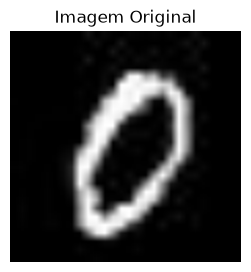

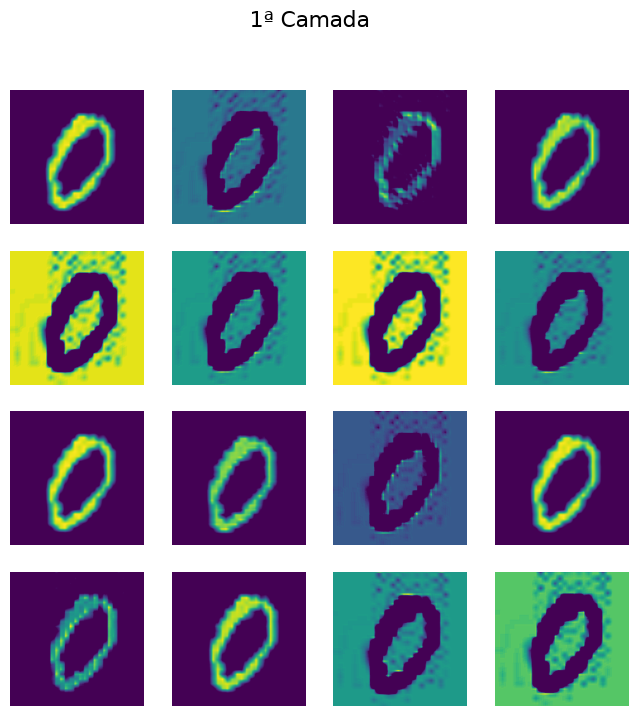

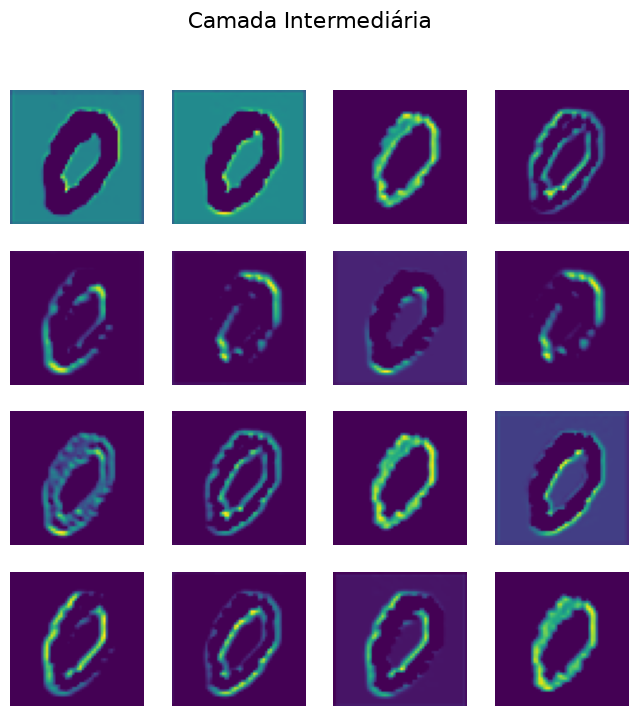

In [21]:
filtros = model.conv1.weight.data.cpu().numpy()

fig_filtros, axes_filtros = plt.subplots(4, 4, figsize=(8, 8))
fig_filtros.suptitle("Filtros da primeira camada Conv1", fontsize=16)

for i, ax in enumerate(axes_filtros.flat):
    filtro = filtros[i] 
    filtro = np.transpose(filtro, (1, 2, 0))
    
    filtro_min, filtro_max = filtro.min(), filtro.max()
    filtro_normalizado = (filtro - filtro_min) / (filtro_max - filtro_min)
    
    ax.imshow(filtro_normalizado)
    ax.axis('off')
plt.show()

filtros_intermediarios = model.conv5.weight.data.cpu().numpy()

fig_filtros_int, axes_filtros_int = plt.subplots(4, 4, figsize=(8, 8))
fig_filtros_int.suptitle("Filtros da Camada Intermediária Conv5", fontsize=16)

for i, ax in enumerate(axes_filtros_int.flat):
    filtro = filtros_intermediarios[i, 0, :, :]
    
    filtro_min, filtro_max = filtro.min(), filtro.max()
    filtro_normalizado = (filtro - filtro_min) / (filtro_max - filtro_min + 1e-8)
    
    ax.imshow(filtro_normalizado)
    ax.axis('off')
plt.show()

indice = 13 
imagem_original, label_real = test_data[indice]

img_tensor = imagem_original.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    # 1ª Camada
    mapa_1 = F.relu(model.bn1(model.conv1(img_tensor)))
    
    x = model.pool(F.relu(model.bn2(model.conv2(mapa_1))))
    x = F.relu(model.bn3(model.conv3(x)))
    x = model.pool(F.relu(model.bn4(model.conv4(x))))
    mapa_intermediario = F.relu(model.bn5(model.conv5(x)))

def plotar_mapas(mapa_tensor, titulo):
    mapas = mapa_tensor.squeeze(0).cpu().numpy()
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    fig.suptitle(titulo, fontsize=16)
    
    for i, ax in enumerate(axes.flat):
        ax.imshow(mapas[i], cmap='viridis')
        ax.axis('off')
    plt.show()

plt.figure(figsize=(3,3))
plt.imshow(np.transpose(imagem_original.cpu().numpy(), (1, 2, 0)))
plt.title(f"Imagem Original")
plt.axis('off')
plt.show()

plotar_mapas(mapa_1, "1ª Camada")
plotar_mapas(mapa_intermediario, "Camada Intermediária")